Now that I have selected the templates I will find the thresholds.

In [1]:
from pathlib import Path
from calibration_calcs import plot_pr_curve, compute_pr_curve, find_threshold_for_precision, find_threshold_fbeta, compute_template_background_dtw_costs, compute_roc_curve, find_threshold_youden_from_roc, compute_auc, plot_roc_curve, plot_dtw_scatter, save_threshold

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"
RESULTS_29.mkdir(exist_ok=True)

DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"
RESULTS_26.mkdir(exist_ok=True)

n_temps = 10
n_calib = 10

single-tone dtws #10

In [2]:
#returns the costs for templates vs background segemnts as well as the pairs
call_st_costs, call_st_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    RESULTS_26 / "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    n_templates=n_temps,
    n_background=n_calib
)

In [3]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json",
    RESULTS_26 / "Bground_CALIB_26_20230426_075505_background.json",
    n_templates=n_temps,
    n_background=n_calib
)

Threshold: 0.1399 (J = 0.9400)


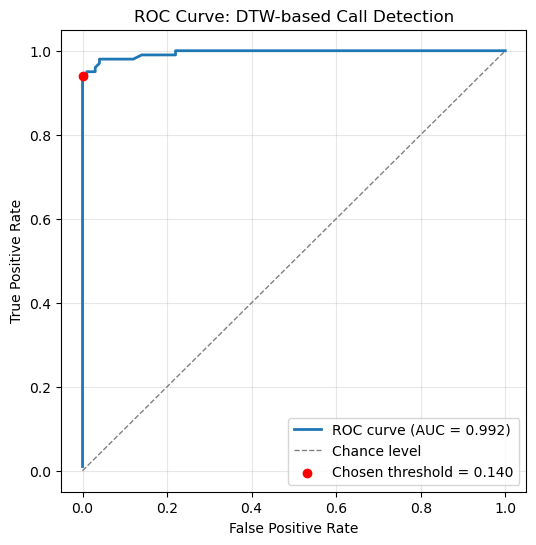

In [4]:
#returns false positive and true positive rates as well as all calculated thresholds
fpr, tpr, thresholds = compute_roc_curve(call_st_costs, call_bg_costs)

#returns threshold and j_stat of the point that maximises the j_stat
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})") #print threshold and j_stat

#returns area under ROC curve
auc = compute_auc(fpr, tpr)

#plots TPR and FPR as well as threshold
plot_roc_curve(call_st_costs, call_bg_costs, best_threshold=threshold);

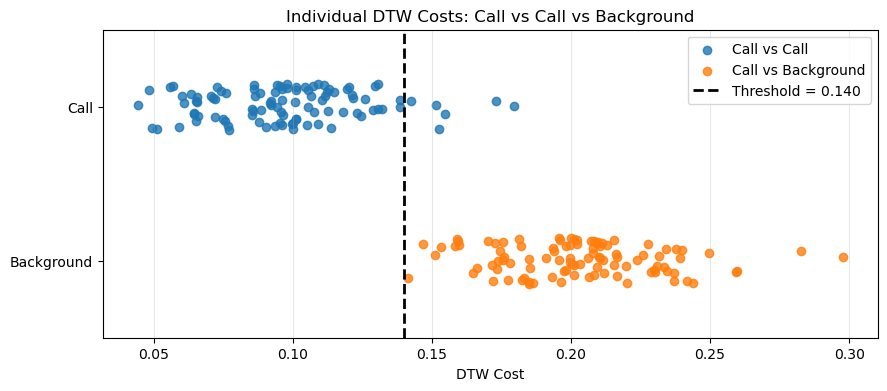

In [5]:

#Plot every individual DTW cost as a point, split into two rows (call-vs-call and call-vs-background)
plot_dtw_scatter(call_st_costs, call_bg_costs, threshold=threshold)

In [6]:
#auc = compute_auc(fpr, tpr)
#save threshold to .json file
save_threshold(
    threshold, j_stat, auc,
    call_type="single_tone",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=n_temps,
    n_background=n_calib
);

Saved threshold for 'single_tone' (20230429_Templates) to 20230429_Templates_single_tone_threshold.json: threshold=0.1399, J=0.9400, AUC=0.9916


multi-tone dtws #10

In [7]:
#returns the costs for templates vs background segemnts as well as the pairs
call_mt_costs, call_mt_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json",
    RESULTS_26 / "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    n_templates=n_temps,
    n_background=n_calib
)

In [8]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json",
    RESULTS_26 / "Bground_CALIB_26_20230426_075505_background.json",
    n_templates=n_temps,
    n_background=n_calib
)

Threshold: 0.1378 (J = 0.8100)


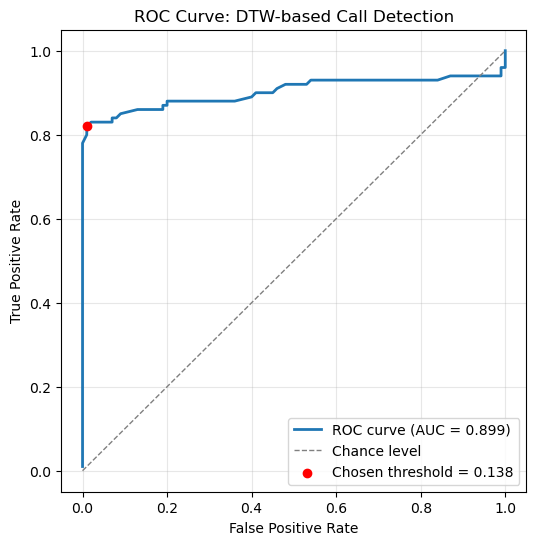

In [9]:
fpr, tpr, thresholds = compute_roc_curve(call_mt_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})")

auc = compute_auc(fpr, tpr)
plot_roc_curve(call_mt_costs, call_bg_costs, best_threshold=threshold);

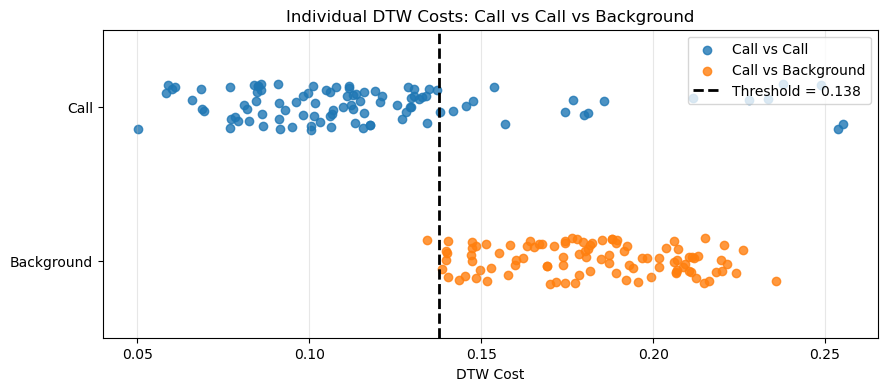

In [10]:
plot_dtw_scatter(call_mt_costs, call_bg_costs, threshold=threshold)

In [11]:
#auc = compute_auc(fpr, tpr)

save_threshold(
    threshold, j_stat, auc,
    call_type="multi_tone",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=n_temps,
    n_background=n_calib
);

Saved threshold for 'multi_tone' (20230429_Templates) to 20230429_Templates_multi_tone_threshold.json: threshold=0.1378, J=0.8100, AUC=0.8988


burst-tonal dtws #10

In [12]:
#returns the costs for templates vs background segemnts as well as the pairs
call_bt_costs, call_bt_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json",
    RESULTS_26 / "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
    n_templates=n_temps,
    n_background=n_calib
)

In [13]:
call_bg_costs, call_bg_pairs = compute_template_background_dtw_costs(
    RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json",
    RESULTS_26 / "Bground_CALIB_26_20230426_075505_background.json",
    n_templates=n_temps,
    n_background=n_calib
)

Threshold: 0.1451 (J = 0.7800)


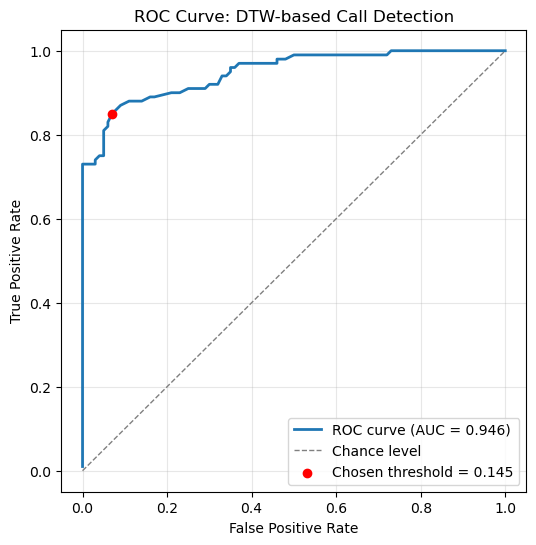

In [14]:
fpr, tpr, thresholds = compute_roc_curve(call_bt_costs, call_bg_costs)
threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)

print(f"Threshold: {threshold:.4f} (J = {j_stat:.4f})")

auc = compute_auc(fpr, tpr)
plot_roc_curve(call_bt_costs, call_bg_costs, best_threshold=threshold);

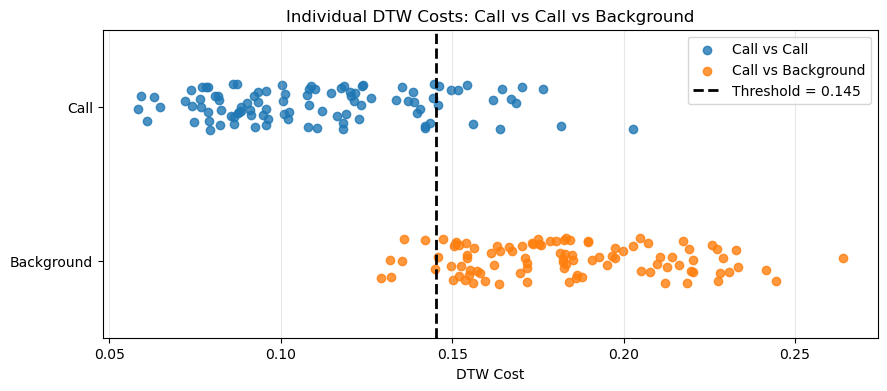

In [15]:
plot_dtw_scatter(call_bt_costs, call_bg_costs, threshold=threshold)

In [16]:
#auc = compute_auc(fpr, tpr)

save_threshold(
    threshold, j_stat, auc,
    call_type="burst_tonal",
    file_label="20230429_Templates",
    results_dir=RESULTS_29,
    n_templates=n_temps,
    n_background=n_calib,
);

Saved threshold for 'burst_tonal' (20230429_Templates) to 20230429_Templates_burst_tonal_threshold.json: threshold=0.1451, J=0.7800, AUC=0.9462
